Delta: wavelength: 406.17699999999996, peak intensity: 1533.94
middle width: 10.015734663516241, top width: 1.546867811735524, saturated: False
Gamma: wavelength: 433.397, peak intensity: 2148.14
middle width: 3.330105909865267, top width: 0.5997767097148312, saturated: False
Beta: wavelength: 485.395, peak intensity: 16853.04
middle width: 3.3828658502405915, top width: 0.41238116434885796, saturated: False
Fulcher: wavelength: 594.311, peak intensity: 3397.34
middle width: 3.197826384415748, top width: 0.5200101483637809, saturated: False
Alpha: wavelength: 655.648, peak intensity: 52220.39
middle width: 3.4591687219951837, top width: 0.6369041074581219, saturated: False


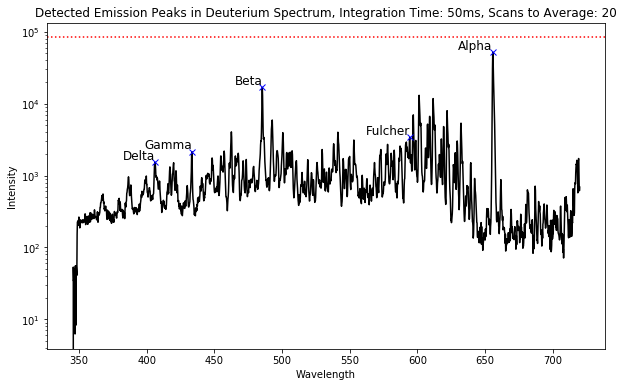

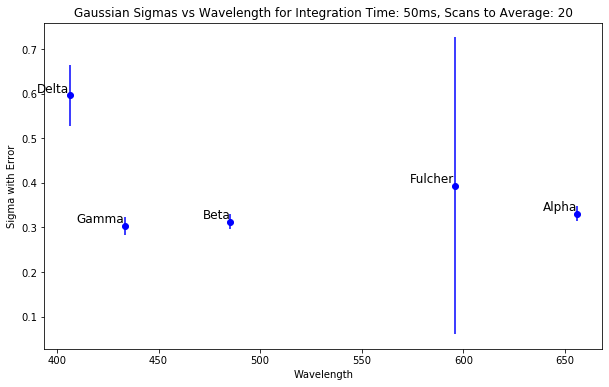

Delta gaussian parameters: H = 613.6864099713241, A = 855.666457943128, x0 = 406.2471482307308, sigma = 0.5967464268324452
errors: 28.082408467701804, 80.39534606025732, 0.06275729695461812, 0.0686017533420511


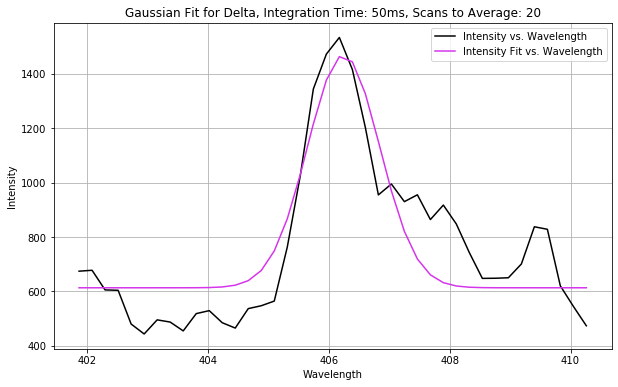

Gamma gaussian parameters: H = 431.02433888021676, A = 1692.8736937406097, x0 = 433.3291797253617, sigma = 0.30346541159644
errors: 21.074525506159002, 93.78869738424841, 0.019184690048036364, 0.019901228277011396


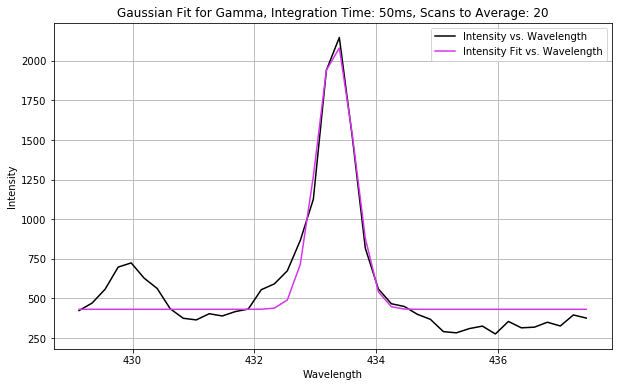

Beta gaussian parameters: H = 1450.5221974287135, A = 14574.088790749336, x0 = 485.4025421885413, sigma = 0.3126137995699087
errors: 154.2798677174087, 668.99698344041, 0.016364972643469138, 0.017018401026885194


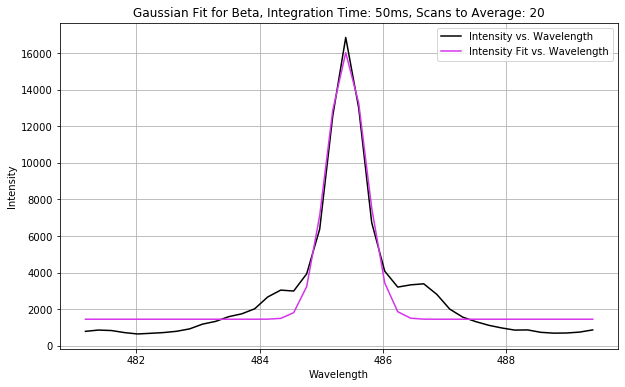

Fulcher gaussian parameters: H = 2448.706453776974, A = -1240.4274020154082, x0 = 595.615200381991, sigma = 0.3936838999379495
errors: 238.15909682787182, 876.2868815985076, 0.3149094277226769, 0.33263231437825125


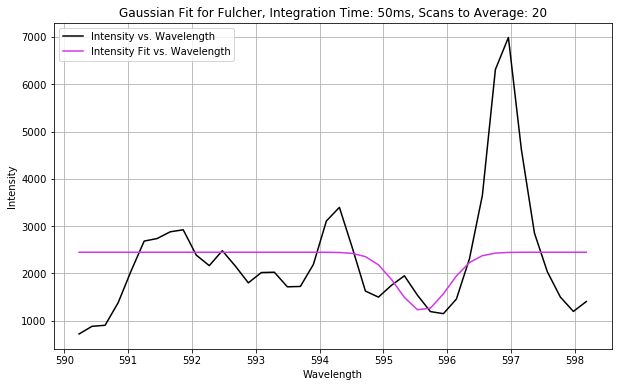

Alpha gaussian parameters: H = 1095.252416633175, A = 48141.06810690073, x0 = 655.7710289507875, sigma = 0.3312345094037134
errors: 531.7866284098756, 2153.0122820077727, 0.0168419387058825, 0.017627297286977265


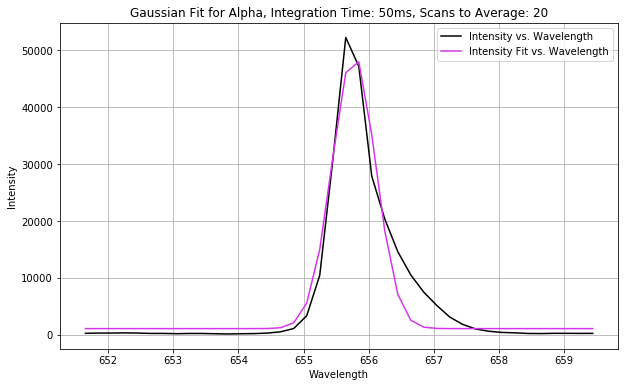

Delta: wavelength: 406.17699999999996, peak intensity: 1488.24667
middle width: 10.34931566883057, top width: 1.5046291011354356, saturated: False
Gamma: wavelength: 433.397, peak intensity: 2100.84667
middle width: 3.4195095948826975, top width: 0.5711750465764567, saturated: False
Beta: wavelength: 485.395, peak intensity: 16753.04667
middle width: 3.384870755701627, top width: 0.4172628231874569, saturated: False
Fulcher: wavelength: 594.311, peak intensity: 3378.54667
middle width: 3.1638030660055847, top width: 0.5229688061203888, saturated: False
Alpha: wavelength: 655.648, peak intensity: 51662.94667
middle width: 3.493908642464021, top width: 0.6661897581457197, saturated: False


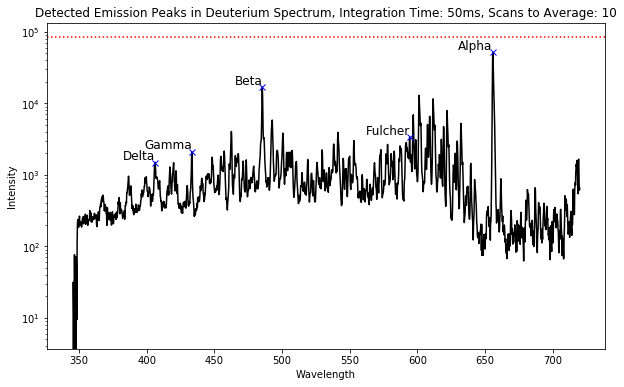

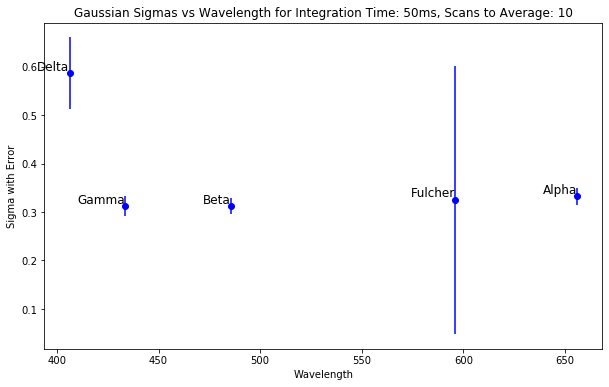

Delta gaussian parameters: H = 603.1262764722361, A = 816.718690196552, x0 = 406.2233805182717, sigma = 0.5868893550520039
errors: 28.79957958778987, 83.47295863755899, 0.0671935197173579, 0.07329511539787813


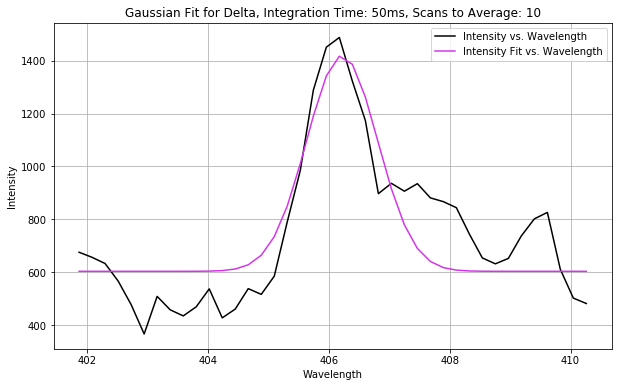

Gamma gaussian parameters: H = 418.5866536125388, A = 1651.5789341391346, x0 = 433.3352534640434, sigma = 0.312361517921652
errors: 21.147647167518173, 92.49632736786837, 0.019950397867265456, 0.020725541089872217


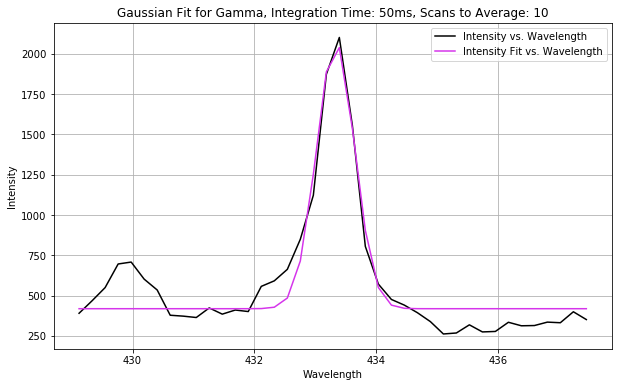

Beta gaussian parameters: H = 1432.6362988197207, A = 14531.269275086159, x0 = 485.4039008304667, sigma = 0.31199169180249153
errors: 151.8948471222684, 659.4455567333359, 0.016147366097184843, 0.016790353689676116


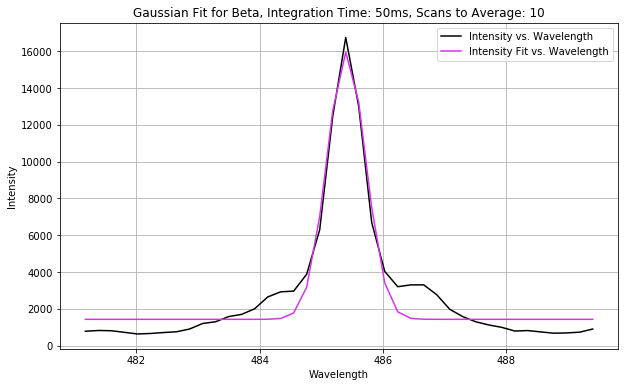

Fulcher gaussian parameters: H = 2390.3949593892016, A = -1323.1514865221516, x0 = 595.7368163315618, sigma = 0.3251297102775247
errors: 228.57331956616596, 948.687208002342, 0.26524010497939005, 0.2767702473123261


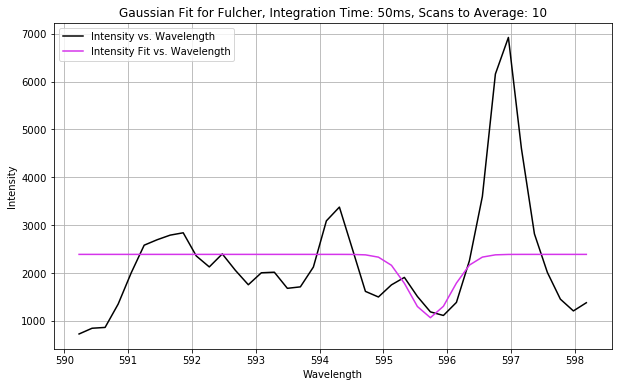

Alpha gaussian parameters: H = 1076.0698441102065, A = 47723.89486754672, x0 = 655.7731757221476, sigma = 0.3325249558265797
errors: 528.8701864159921, 2136.0153404065773, 0.01691953811007095, 0.017711946351138496


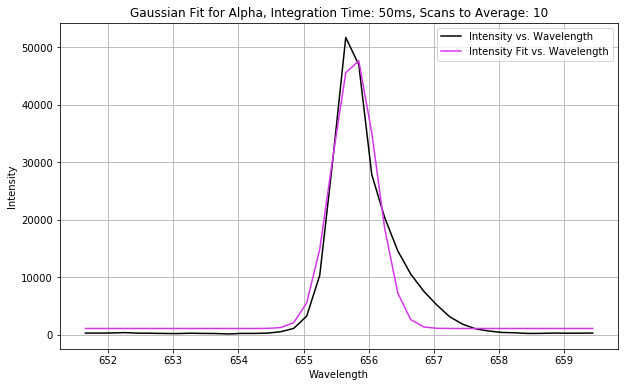

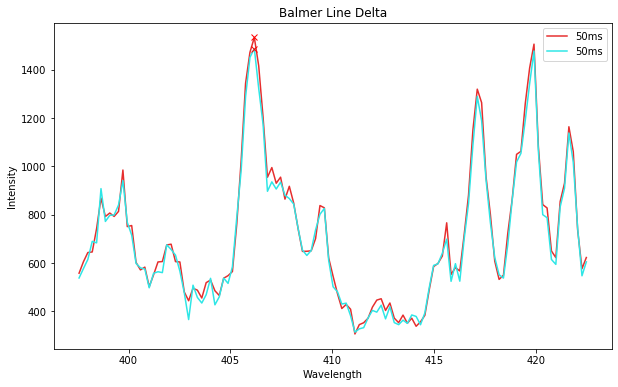

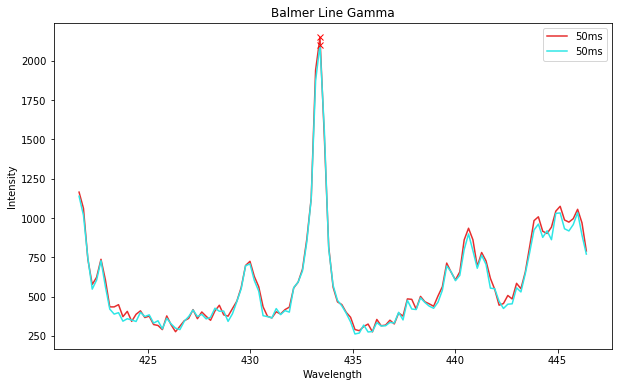

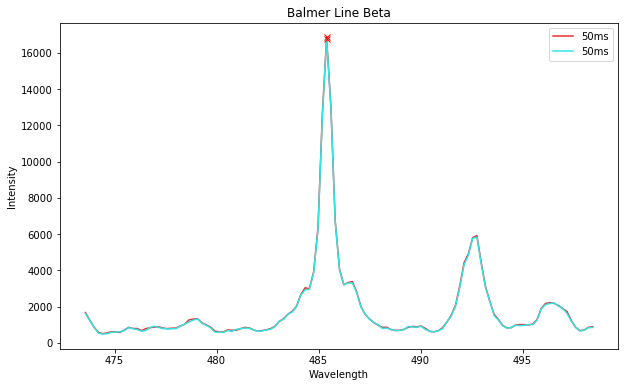

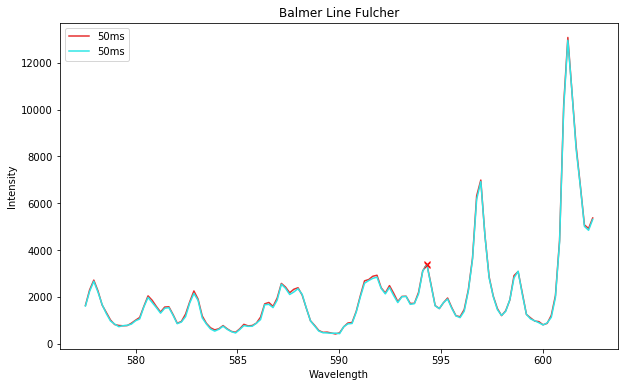

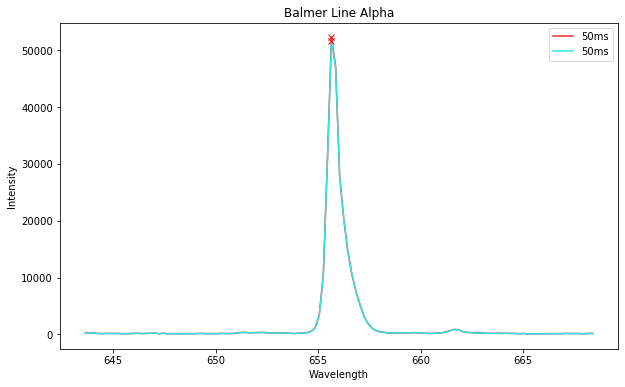

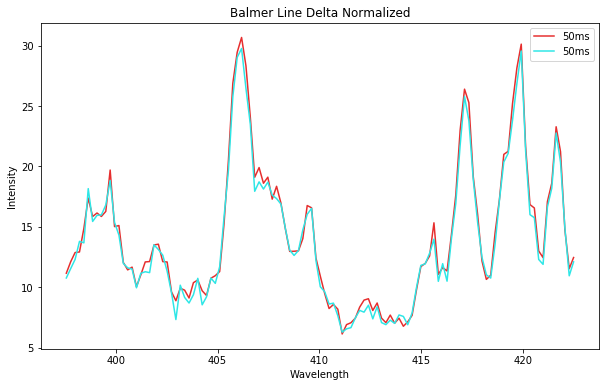

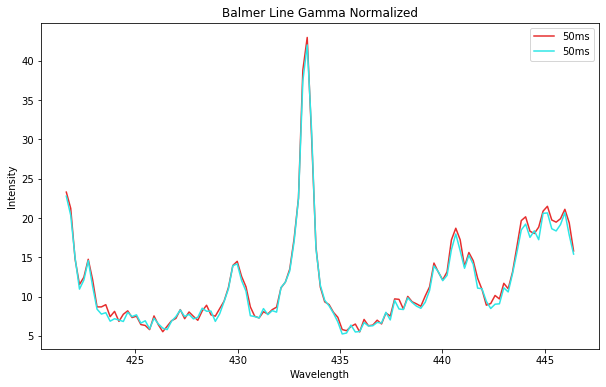

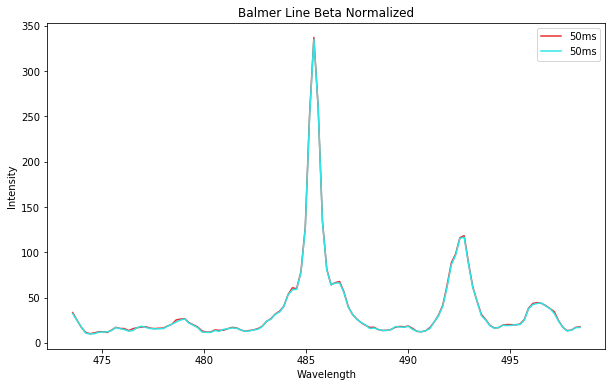

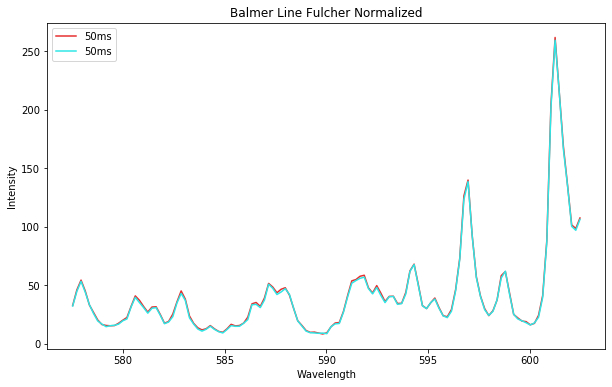

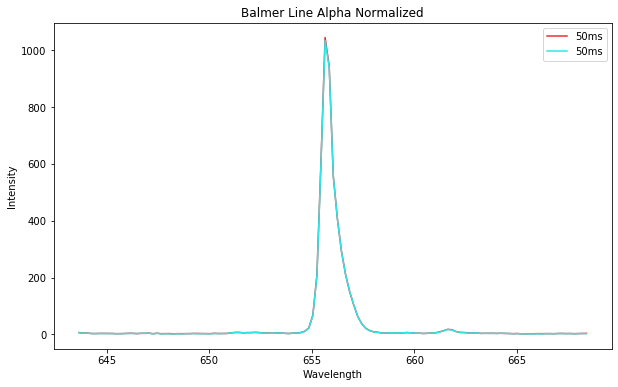

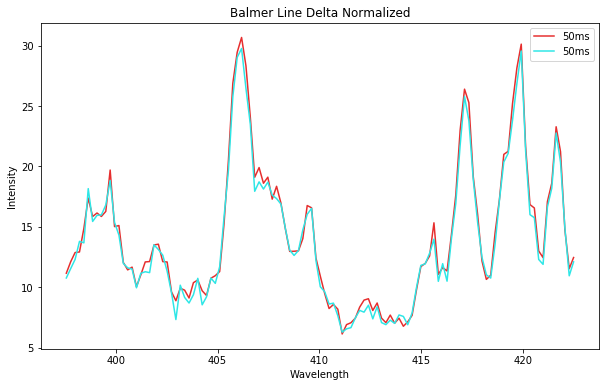

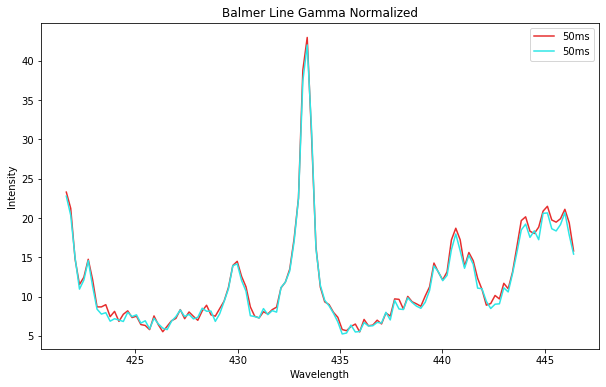

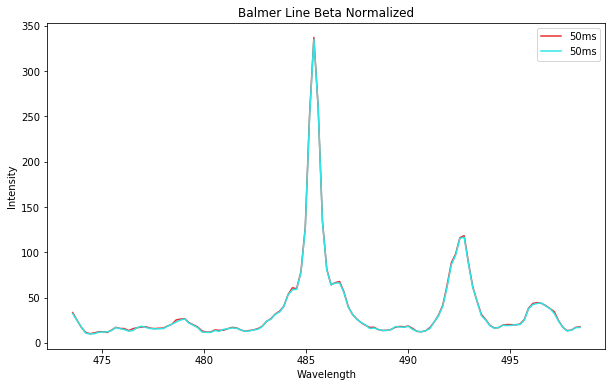

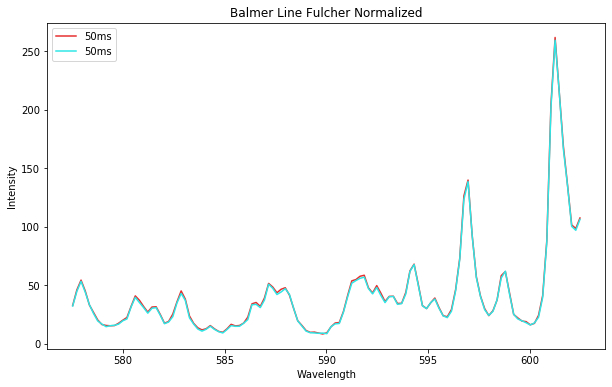

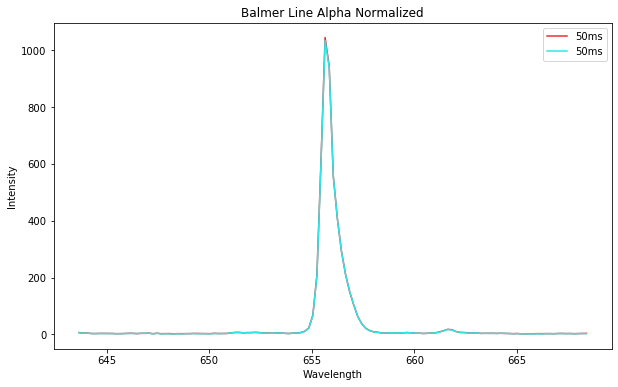

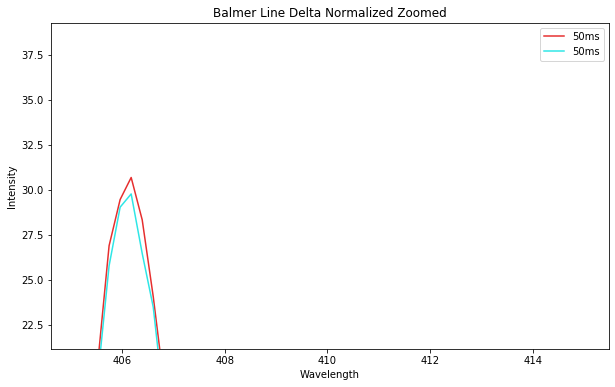

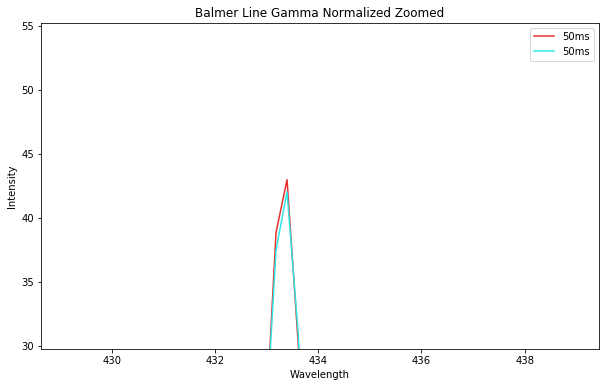

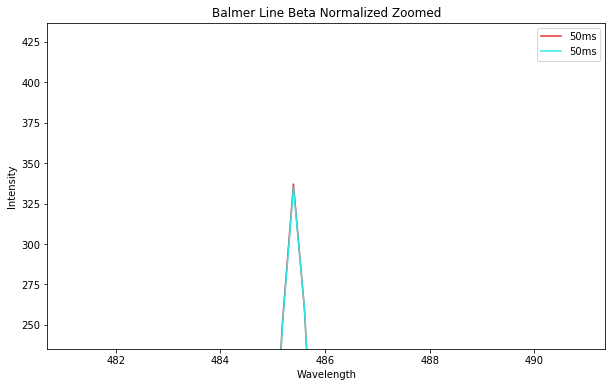

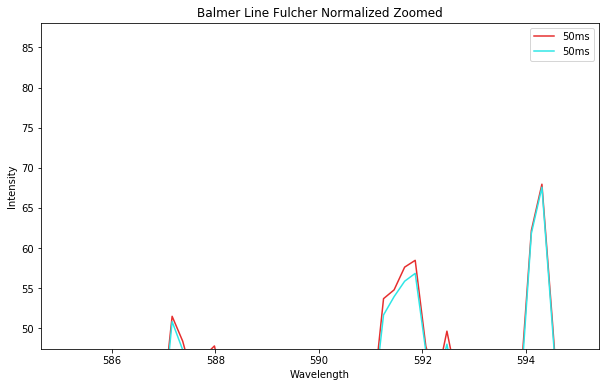

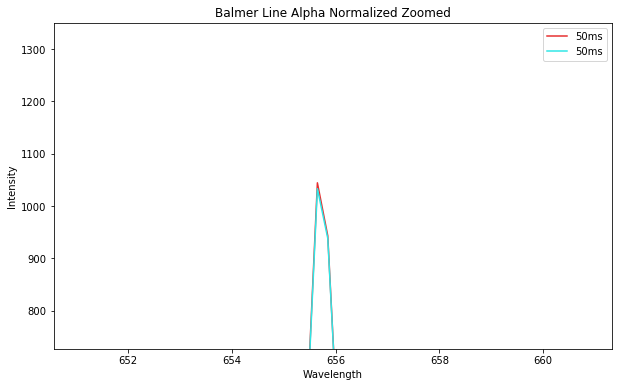

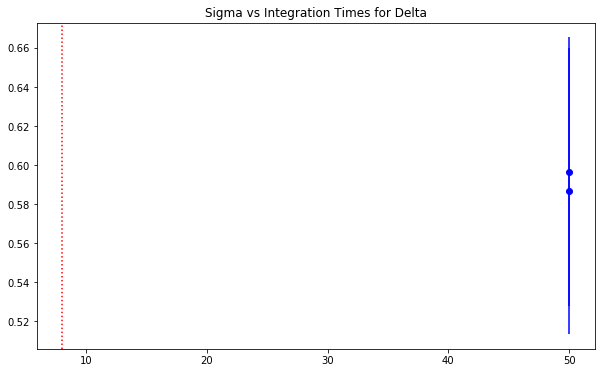

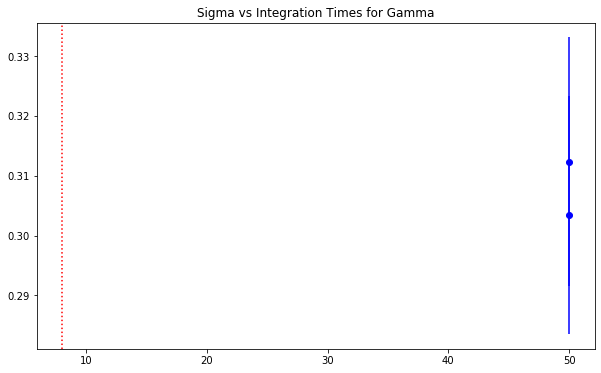

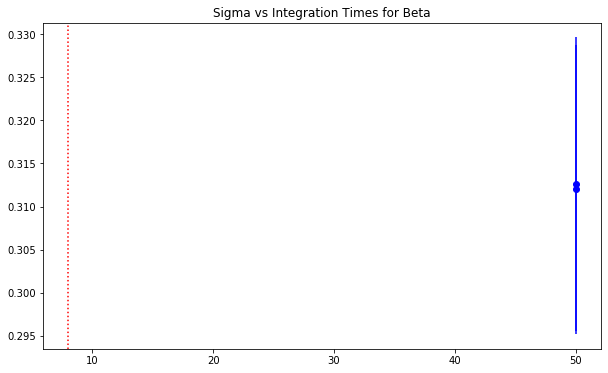

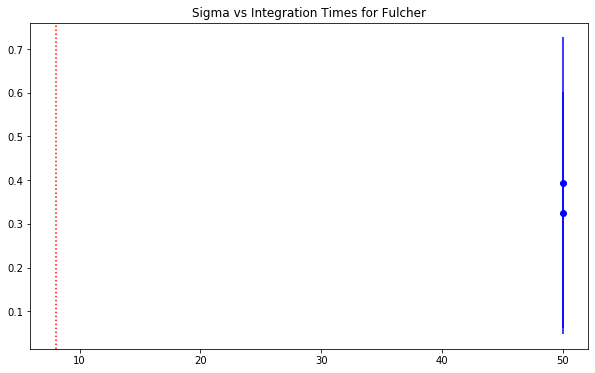

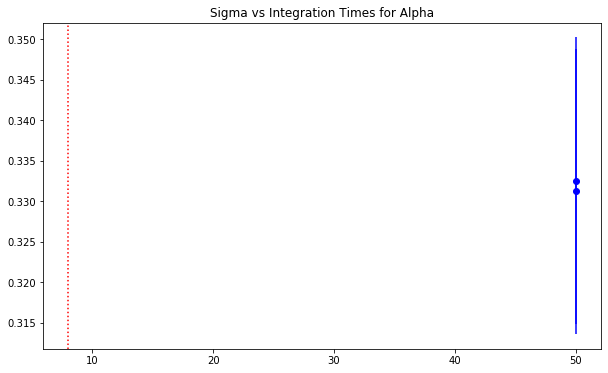

sigma_ratio of Beta to Gamma: [8.57871828e-06 8.80781541e-06]


<ipython-input-3-5bd80065cad0>:354: RankWarning: Polyfit may be poorly conditioned
  experiment.graph_all_area_ratios("Beta", "Gamma")


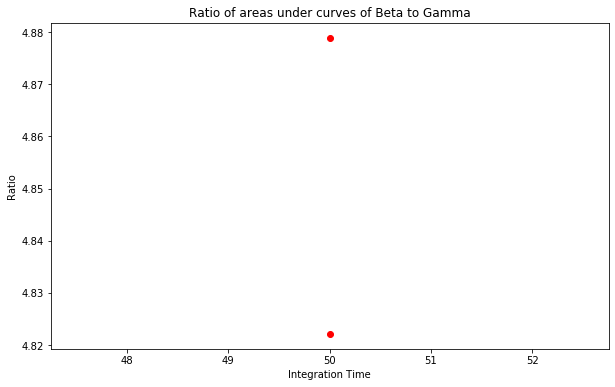

In [3]:
from pathlib import Path
import pandas as pd
from scipy.signal import find_peaks, peak_widths
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import colorsys
import os

# Dict of balmer lines and expected wavelengths
balmer_lines = {"Delta": 410, "Gamma": 434, "Beta": 486, "Fulcher": 590, "Alpha": 656}

trial_time_product = 550

def gauss(data, H, A, x0, sigma):
    return H + A * np.exp(-(data - x0) ** 2 / (2 * sigma ** 2))

def get_fit_errors(covariance_matrix):
    errors = []
    (num_parameters, _) = covariance_matrix.shape
    for i in range(num_parameters):
        errors.append(np.sqrt(np.diag(covariance_matrix))[i])
    return errors

def is_saturated(width_middle, width_top):
    if width_top / width_middle > 0.5:
        return True
    return False

class Trial:
    def __init__(self, file, saturation_line=None):
        self.file = file
        self.saturation_line = saturation_line
        self.integration_time, self.scans_to_average = self.parse_filename()
        self.data = self.read_data()
        self.peak_names, \
            self.peak_indices, \
            self.peak_wavelengths, \
            self.peak_intensities, \
            self.widths_middle, \
            self.widths_top, \
            self.saturated = self.find_peaks()
        
        self.H_params, \
            self.H_param_errors, \
            self.A_params, \
            self.A_param_errors, \
            self.x0_params, \
            self.x0_param_errors, \
            self.sigma_params, \
            self.sigma_param_errors = self.fit_all_balmer_lines()
        
    def parse_filename(self):
        parts = self.file.stem.split('_')
        assert len(parts) >= 8, "Found {} parts in the filename, should be at least 8".format(len(parts))
        assert parts[1][-2:] == "ms", "Integration time is in {}, should be in ms".format(parts[2][-2:])
        time = int(parts[1][:-2])
        return (time, parts[2])
        
    def read_data(self, skiprows=14):
        data = pd.read_csv(self.file.resolve(), skiprows=skiprows)
        data.columns = ['Wavelength', 'Intensity']
        return data

    def balmer_line_window(self, line, range_size):
        half_range_size = range_size / 2
        balmer_wavelength = balmer_lines[line]
        window_start = balmer_wavelength - half_range_size
        window_end = balmer_wavelength + half_range_size
        data_window = self.data.loc[(self.data['Wavelength'] >= window_start) & (self.data['Wavelength'] <= window_end)]
        return data_window

    def find_peaks(self):
        names = []
        indices = []
        wavelengths = []
        intensities = []
        widths_middle = []
        widths_top = []
        saturated = []
        for name, _ in balmer_lines.items():
            data_window = self.balmer_line_window(line=name, range_size=10)

            if data_window.empty:
                continue

            # Find the index with the max intensity, this is a peak
            peak_index = int(data_window['Intensity'].idxmax())
            peak_wavelength = data_window['Wavelength'][peak_index]
            peak_intensity = data_window['Intensity'][peak_index]
            assert peak_intensity == data_window['Intensity'].max(), "Indexmax should yield the max"
            
            width_middle = peak_widths(self.data['Intensity'], [peak_index], rel_height=0.5)[0][0]
            width_top = peak_widths(self.data['Intensity'], [peak_index], rel_height=0.05)[0][0]
            
            names.append(name)
            indices.append(peak_index)
            wavelengths.append(peak_wavelength)
            intensities.append(peak_intensity)
            widths_middle.append(width_middle)
            widths_top.append(width_top)
            saturated.append(is_saturated(width_middle, width_top))

        return (names, indices, wavelengths, intensities, widths_middle, widths_top, saturated)

    def graph_raw(self):
        data_graph = self.data.loc[(self.data['Wavelength'] >= 0) & (self.data['Wavelength'] <= 720)]
        plt.figure(figsize=(10, 6))
        plt.title("Detected Emission Peaks in Deuterium Spectrum, Integration Time: {}ms, Scans to Average: {}".format(self.integration_time, self.scans_to_average))
        plt.plot(data_graph['Wavelength'], data_graph['Intensity'], label="Intensity vs. Wavelength", color="k")
        plt.axhline(y=self.saturation_line, color='red', linestyle=':', linewidth=1.5)
        plt.xlabel('Wavelength')
        plt.ylabel('Intensity')
        plt.yscale('log')
        for i, (name, x, y) in enumerate(zip(self.peak_names, self.peak_wavelengths, self.peak_intensities)):
            color = 'red' if self.saturated[i] else 'blue'
            plt.plot(x, y, "x", color=color)
            plt.text(x, y, name, fontsize=12, ha='right', va='bottom')
            print("{}: wavelength: {}, peak intensity: {}".format(name, x, y))
            print("middle width: {}, top width: {}, saturated: {}".format(self.widths_middle[i], self.widths_top[i], self.saturated[i]))
        plt.show()
        
    def balmer_fit_window(self, line, range_size=40):
        try:
            peak_index = self.peak_names.index(line)
            half_range_size = range_size / 2
            start = int(self.peak_indices[peak_index] - half_range_size)
            end = int(self.peak_indices[peak_index] + half_range_size)
            return (start, end)
        except ValueError:
            print("No peak found for {}".format(line))
            return None
        
    def fit_balmer_line(self, line):
        try:
            peak_index = self.peak_names.index(line)
            guess = [0, self.peak_intensities[peak_index], self.peak_wavelengths[peak_index], 1]
            start, end = self.balmer_fit_window(line)
            res = curve_fit(gauss, self.data['Wavelength'][start:end], self.data['Intensity'][start:end], guess)
            (H, A, x0, sigma) = (res[0][0], res[0][1], res[0][2], res[0][3])
            (H_error, A_error, x0_error, sigma_error) = get_fit_errors(res[1])
            return (H, H_error, A, A_error, x0, x0_error, sigma, sigma_error)
        except ValueError:
            print("No peak found for {}".format(line))
            return None
        
    def fit_all_balmer_lines(self):
        H_params = []
        H_param_errors = []
        A_params = []
        A_param_errors = []
        x0_params = []
        x0_param_errors = []
        sigma_params = []
        sigma_param_errors = []
        for line in self.peak_names:
            (H, H_error, A, A_error, x0, x0_error, sigma, sigma_error) = self.fit_balmer_line(line)
            H_params.append(H)
            H_param_errors.append(H_error)
            A_params.append(A)
            A_param_errors.append(A_error)
            x0_params.append(x0)
            x0_param_errors.append(x0_error)
            sigma_params.append(sigma)
            sigma_param_errors.append(sigma_error)
            
        return (H_params, H_param_errors, A_params, A_param_errors, x0_params, x0_param_errors, sigma_params, sigma_param_errors)
        
    def plot_all_fits(self):
        for i, line in enumerate(self.peak_names):
            plt.figure(figsize=(10, 6))
            plt.title("Gaussian Fit for {}, Integration Time: {}ms, Scans to Average: {}".format(line, self.integration_time, self.scans_to_average))
            start, end = self.balmer_fit_window(line)
            plt.plot(self.data['Wavelength'][start:end], self.data['Intensity'][start:end], label="Intensity vs. Wavelength", color="k")
            plt.plot(self.data['Wavelength'][start:end], gauss(self.data['Wavelength'][start:end], self.H_params[i], self.A_params[i], self.x0_params[i], self.sigma_params[i]), label="Intensity Fit vs. Wavelength", color="#d534eb")
            plt.xlabel('Wavelength')
            plt.ylabel('Intensity')
            plt.legend()
            plt.grid(True)
            print("{} gaussian parameters: H = {}, A = {}, x0 = {}, sigma = {}\nerrors: {}, {}, {}, {}".format(line, self.H_params[i], self.A_params[i], self.x0_params[i], self.sigma_params[i], self.H_param_errors[i], self.A_param_errors[i], self.x0_param_errors[i], self.sigma_param_errors[i]))
            plt.show()
            
    def plot_sigma_vs_wavelength(self):
        plt.figure(figsize=(10, 6))
        plt.title("Gaussian Sigmas vs Wavelength for Integration Time: {}ms, Scans to Average: {}".format(self.integration_time, self.scans_to_average))
        plt.xlabel('Wavelength')
        plt.ylabel('Sigma with Error')
        for i, (name, x, y) in enumerate(zip(self.peak_names, self.x0_params, self.sigma_params)):
            color = 'red' if self.saturated[i] else 'blue'
            plt.errorbar(self.x0_params[i], self.sigma_params[i], yerr=self.sigma_param_errors[i], fmt='o', label="Errors", color=color)
            plt.text(x, y, name, fontsize=12, ha='right', va='bottom')
        plt.show()
        
    def area_under_balmer_line(self, line):
        try:
            start, end = self.balmer_fit_window(line)
            # return np.trapz(self.data['Intensity'][start:end], self.data['Wavelength'][start:end])
            # changed from finding actual area to averaging the heights on the curves
            #return self.data['Intensity'][start:end].sum() / len(self.data['Intensity'][start:end])
            #return self.data['Intensity'][start:end].sum() 
            return self.data['Intensity'][start:end].sum()*(trial_time_product)/(self.integration_time)

        except ValueError:
            print("No peak found for {}".format(line))
            return None
        
class Experiment:
    def __init__(self, folder, saturation_line=None):
        self.folder = folder
        
        os.makedirs("{}_plots".format(self.folder), exist_ok=True)
        
        self.trials = []
        self.saturation_line = saturation_line
        for file in folder.iterdir():
            if file.is_file():
                trial = Trial(file, saturation_line)
                
                # if trial.integration_time > 10 and trial.integration_time < 160:
                #     self.trials.append(trial)
                self.trials.append(trial)

        self.trials = sorted(self.trials, key=lambda t: t.integration_time)
        self.colors = self.get_colors()
                
    def graph_all(self):
        for t in self.trials:
            t.graph_raw()
            t.plot_sigma_vs_wavelength()
            t.plot_all_fits()
            
    def get_colors(self):
        num_colors = len(self.trials)
        return [colorsys.hsv_to_rgb(i / num_colors, 0.8, 0.9) for i in range(num_colors)]
            
    def graph_balmer_line_combined(self, balmer_line, range_size, normalized=False, trials=None, zoom=False):
        plt.figure(figsize=(10, 6))
        title = "Balmer Line {}{}{}".format(balmer_line, " Normalized" if normalized else "", " Zoomed" if zoom else "")
        plt.title(title)
        plot_trials = self.trials
        average_peak = 0
        if trials:
            plot_trials = [t for t in plot_trials if t.integration_time in trials]
        for t, color in zip(plot_trials, self.colors):
            balmer_range = t.balmer_line_window(balmer_line, range_size)
            if normalized:
                plt.plot(balmer_range['Wavelength'], balmer_range['Intensity'] / t.integration_time, label="{}ms".format(t.integration_time), color=color)
                
                if zoom:
                    peak = balmer_range['Intensity'].max() / t.integration_time
                    average_peak += peak
                    # single_peak_average = balmer_range['Intensity'].sum() / len(balmer_range['Intensity'])
                    # average_peak += single_peak_average
            else:
                plt.plot(balmer_range['Wavelength'], balmer_range['Intensity'], label="{}ms".format(t.integration_time), color=color)
            plt.xlabel('Wavelength')
            plt.ylabel('Intensity')

            if not normalized:
                try:
                    peak_index = t.peak_names.index(balmer_line)
                    plt.plot(t.peak_wavelengths[peak_index], t.peak_intensities[peak_index], "x", color="r")
                except ValueError:
                    print("No peak found for {}".format(balmer_line))
                    
        if normalized and zoom:
            average_peak /= len(plot_trials)
            plt.ylim(average_peak * .7, average_peak * 1.3)
        plt.legend()
        plt.savefig("{}_plots/{}_{}{}_gt10.pdf".format(self.folder, title.replace(" ", "_"), "_".join(map(str, trials)) if trials else "all_trials", "_normalized" if normalized else ""))
        plt.show()
        
    def graph_all_balmer_lines_combined(self, range_size, normalized=False, trials=None, zoom=False):
        # Go through all balmer lines, and call graph_balmer_line_combined with each
        for line in balmer_lines:
            self.graph_balmer_line_combined(line, range_size, normalized, trials=trials, zoom=zoom)
            
    def graph_sigma_vs_integration_time(self, balmer_line):
        plt.figure(figsize=(10, 6))
        plt.title("Sigma vs Integration Times for {}".format(balmer_line))
        # Vertical line where alpha integrates
        plt.axvline(x=8, color='red', linestyle=':', linewidth=1.5)
        for t in self.trials:
            try:
                peak_index = t.peak_names.index(balmer_line)
                color = 'red' if t.saturated[peak_index] else 'blue'
                plt.errorbar(t.integration_time, t.sigma_params[peak_index], yerr=t.sigma_param_errors[peak_index], fmt='o', color=color)
            except ValueError:
                print("No peak found for {}".format(balmer_line))
        plt.show()
    
    def graph_all_sigmas_vs_integration_times(self):
        # Go through all balmer lines, and call graph_sigma_vs_integration_time with each
        for line in balmer_lines:
            self.graph_sigma_vs_integration_time(line)

    def graph_all_area_ratios(self, balmer_line_1, balmer_line_2):
        plt.figure(figsize=(10,6))
        plt.title("Ratio of areas under curves of {} to {}".format(balmer_line_1, balmer_line_2))
        plt.xlabel("Integration Time")
        plt.ylabel("Ratio")

        integration_times = []
        ratios = []
        line_1_areas = []
        line_2_areas = []

        for t in self.trials:
            line_1_area = t.area_under_balmer_line(balmer_line_1)
            line_2_area = t.area_under_balmer_line(balmer_line_2)
            ratio = line_1_area / line_2_area

            integration_times.append(t.integration_time)
            ratios.append(ratio)
            line_1_areas.append(line_1_area)
            line_2_areas.append(line_2_area)

            # plt.plot(t.integration_time, ratio, "o", color='red')

        # Poisson error calculation
        x = np.array(integration_times)
        y = np.array(ratios) # ratios = area1/area2
        line_1_areas = np.array(line_1_areas) #A1
        line_2_areas = np.array(line_2_areas) #A2
        
        # σ=N^1/2
        sigma_1 = np.sqrt(line_1_areas) # A1^1/2
        sigma_2 = np.sqrt(line_2_areas) # A2^1/2
        # sigma_ratio = np.sqrt((sigma_1 / line_2_areas) ** 2 + (line_1_areas * sigma_2 / line_2_areas ** 2) ** 2)
        sigma_ratio = (line_1_areas / line_2_areas) * np.sqrt((1 / line_1_areas) * (1 / line_2_areas))
        print("sigma_ratio of {} to {}: {}".format(balmer_line_1, balmer_line_2, sigma_ratio))
        
        #σR2=(∂A1*∂R)2σ12+(∂A2*∂R)2σ22
        #σR=((σ1/A2)^2 + (A1σ2/A2^2)^2)
        
        plt.errorbar(x, y, yerr=sigma_ratio, fmt='o', color='red')

        m, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = m * x_line + b
        plt.plot(x_line, y_line)
        plt.show()

# Example file name: deutdg_200ms_20_SR4014911__0__16-45-59-520.csv,
# where 200 is integration time, 20 is scans to average
folder = Path("/home/crystal/research/deuterium_analysis/310data")
experiment = Experiment(folder=folder, saturation_line=83500)
experiment.graph_all()
experiment.graph_all_balmer_lines_combined(25)
experiment.graph_all_balmer_lines_combined(25, normalized=True)
experiment.graph_all_balmer_lines_combined(25, normalized=True)
experiment.graph_all_balmer_lines_combined(10, normalized=True, zoom=True)
experiment.graph_all_sigmas_vs_integration_times()
experiment.graph_all_area_ratios("Beta", "Gamma")

7/21:  
make log plot instead of line plot for full spectrum  
make another normalized plot with 4, 40, 80 (can just do a noise part, do not have to do peak)  
plot fulcher for 100 ms  
abstract  

7/28
more on abstract

In [2]:
# area_under_balmer_line
     # changed from finding actual area to averaging the heights on the curves
    
    dont do poisson on averaged one
    
    area under curve part
                #return self.data['Intensity'][start:end].sum() / len(self.data['Intensity'][start:end])
multiply N by number of trials because we averaged on ocean optics



IndentationError: unexpected indent (<ipython-input-2-8b5ea2510d40>, line 4)